# Multi-Telescope Configuration

## Telescope Groups

The 32 telescopes are arranged in 4 groups of 8 telescopes:
- all 8 cameras of each group have exactly the same field-of-view</li>
- the lines-of-sight of the 4 groups are offset by an angle of 9.2° from the PLM +Z axis</li>

<img src="telescopeGroups.png">

→ per group:

- same tilt & azimuth angle
- all telescopes within the same group will observe the target with the same CCD

## Tilt & Azimuth Angle

<img src="tiltAzimuth.png">

## Resulting FOV Configuration

<img src="fov.png">

# Scripting Multi-Telescope Configuration in Python

In [1]:
%matplotlib inline
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = (10,10)

## Where is my stuff located?

In [2]:
import os
baseDir = os.getenv("PLATO_PROJECT_HOME")
workDir = os.getenv("PLATO_WORKDIR")
print(workDir)
print(baseDir)

import sys
sys.path.append(baseDir + "/python")

/Users/sara/work/Instrumentation/Plato/workdir/
/Users/sara/work/Instrumentation/Plato/softwareDevelopment/PlatoSim3


## Importing

In [3]:
import os
import math
import numpy as np
from simulation import Simulation
import referenceFrames as rf
from plot import drawCCDsInSkyMollweide
from referenceFrames import CCD

## Where to find the input parameters and where to store the output?

In [4]:
inputDir = baseDir + "/inputfiles"
inputFile   = inputDir + "/inputfile.yaml"

outputDir   = workDir
outputPrefix = "MultiTelescopeConfiguration"

## Configuration Parameters

### Observing Parameters

In [5]:
raPlatform  = 10.0                      # Platform right ascension pointing coordinate [degrees]
decPlatform = 10.0                      # Platform declination pointing coordinate [degrees]

raCenter  = 7.0                         # Right ascension on which to centre the sub-field [degrees]
decCenter = 15.0                        # Declination on which to centre the sub-field [degrees]

numTelescopeGroups = 4                  # Number of telescope groups
numTelescopesPerGroup = 8               # Number of telescopes per group

### Telescope Parameters

In [6]:
#azimuthAngles = [45, 135, -135, -45]    # Azimuth angles of the telescopes (same within a group) [degrees]
#tiltAngle = 9.2                         # Tilt angle of the telescopes (same for the 4 groups) [degrees]

driftSeed = 1433429158                  # Random seed for telescope drift (different for each telescope!)

### CCD Parameters (different for each telescope)

In [7]:
readoutNoiseSeed =  1424949740          # Random seed for the readout noise
photonNoiseSeed = 1433320336            # Random seed for the photon noise
flatfieldSeed = 1433320381              # Random seed for the flatfield

### Sub-Field Parameters

In [8]:
numColumnsSubField = 10                 # Number of columns in the modelled sub-field [pixels]
numRowsSubField = 10                    # Number of rows in the modelled sub-field [pixels]

## Simulations

For each telescope in each group:
- platform pointing & (tilt, azimuth) -> telescope pointing
- which CCD selected?
- sub-field falls entirely on selected CCD -> simulation


In [9]:
raTelescopePointings = []
decTelescopePointings = []

# Loop over all groups of telescopes

for group in range(numTelescopeGroups):
    
    # Loop over all telescopes in the current group
    
    for telescope in range(numTelescopesPerGroup):
        
        print("Processing telescope {0} of group {1}".format(telescope + 1, group + 1))
        
        telescopeIndex = numTelescopesPerGroup * group + telescope
        
        # Output will be stored in multiTelescopeConfiguration_group<group>_telescope<telescope>
        
        outputFilePrefix = outputPrefix + "_group" +  "{0:02d}".format(group+1) + "_telescope" + "{0:02d}".format(telescope+1)
        sim = Simulation(outputFilePrefix, inputFile)
        sim.outputDir = outputDir
        
        azimuthAngles = sim["CameraGroups/AzimuthAngle"]
        tiltAngles = sim["CameraGroups/TiltAngle"]
        solarPanelOrientation = np.deg2rad(float(sim["Platform/SolarPanelOrientation"]))      # [rad]
        
        # Compute the telescope pointing, based on the platform pointing, and the tilt and azimuth angle of the telescope
        
        raSun, decSun = rf.sunSkyCoordinatesAwayfromPlatformPointing(np.deg2rad(raPlatform), np.deg2rad(decPlatform), solarPanelOrientation)
        raTelescope, decTelescope = rf.platformToTelescopePointingCoordinates(math.radians(raPlatform), math.radians(decPlatform), raSun, decSun, math.radians(azimuthAngles[group]), math.radians(tiltAngles[group]))
        raTelescopePointings.append(np.rad2deg(raTelescope))
        decTelescopePointings.append(np.rad2deg(decTelescope))
        
        print("Platform pointing: {0}, {1}".format(raPlatform, decPlatform))
        print("Telescope pointing: {0}, {1}".format(np.rad2deg(raTelescope), np.rad2deg(decTelescope)))
        print("Sun: {0}, {1}".format(math.degrees(raSun), math.degrees(decSun)))
        
        includeFieldDistortion = (sim["Camera/IncludeFieldDistortion"] == "no")        # Whether or not to include field distortion
        distortionCoefficients = sim["Camera/FieldDistortion/ConstantCoefficients"]
        focalPlaneAngle        = sim["Camera/FocalPlaneOrientation/ConstantValue"]     # Focal-plane orientation [degrees]
        focalLength            = sim["Camera/FocalLength/ConstantValue"] * 1000        # Focal length [mm]
        plateScale             = sim["Camera/PlateScale"]                              # Plate scale [arcsec / micron]
        pixelSize              = sim["CCD/PixelSize"]                                  # Pixel size [micron / pixel]
        
        # Determine on which CCD (1, 2, 3, or 4) the coordinates (raCenter, decCenter) are positioned and at which location
        # (in pixel coordinates)
        
        ccdCode, columnCenter, rowCenter = rf.getCCDandPixelCoordinates(math.radians(raCenter), math.radians(decCenter), math.radians(raPlatform), math.radians(decPlatform), solarPanelOrientation, math.radians(tiltAngles[group]), math.radians(azimuthAngles[group]), math.radians(focalPlaneAngle), focalLength, pixelSize, includeFieldDistortion, distortionCoefficients, normal = True)
        #print(ccdCode, columnCenter, rowCenter)
        
        # Check whether the sub-field falls entirely on the detector
        
        if (ccdCode != None) and (rowCenter - numRowsSubField / 2 >= 0) and (rowCenter + numRowsSubField / 2 < CCD[ccdCode]["Nrows"]) and (columnCenter - numColumnsSubField / 2 >= 0) and (columnCenter + numColumnsSubField / 2 < CCD[ccdCode]["Ncols"]):
            
            print("CCD {0} selected".format(ccdCode) +"\n")
            
            # Observing parameters
        
            sim["ObservingParameters/RApointing"] = raPlatform#Pointing
            sim["ObservingParameters/DecPointing"] = decPlatform#Pointing
        
            # Telescope parameters
            
            sim["Telescope/GroupID"] = group + 1
    
            # CCD parameters
        
            sim["CCD/Position"] =  ccdCode
            
            # Sub-field parameters
        
            sim["SubField/ZeroPointRow"] = int(rowCenter - numRowsSubField / 2)
            sim["SubField/ZeroPointColumn"] = int(columnCenter - numColumnsSubField / 2)
        
            sim["SubField/NumColumns"] = numColumnsSubField
            sim["SubField/NumRows"] = numRowsSubField
        
            # Seed parameters
        
            sim["RandomSeeds/ReadOutNoiseSeed"] = readoutNoiseSeed + telescopeIndex
            sim["RandomSeeds/PhotonNoiseSeed"] = photonNoiseSeed + telescopeIndex
            sim["RandomSeeds/FlatFieldSeed"] = flatfieldSeed + telescopeIndex 
            sim["RandomSeeds/DriftSeed"] = driftSeed + telescopeIndex  
            
            print(sim.runName)
            
            simFile = sim.run()
            
        else:
            print("Sub-field centred on ({0}, {1}) does not lay entirely on a CCD for telescope {2} of group {3}".format(raCenter, decCenter, telescope + 1, group + 1))
            
            
raTelescopePointings = np.array(raTelescopePointings)
decTelescopePointings = np.array(decTelescopePointings)

Processing telescope 1 of group 1
Platform pointing: 10.0, 10.0
Telescope pointing: 16.727468494896065, 16.465943737560156
Sun: 192.06657072487673, -5.178691321318966
CCD 1 selected

MultiTelescopeConfiguration_group01_telescope01

2019-10-02 11:10:13 WARNING Simulation: no information about detected stars to write to HDF5
2019-10-02 11:10:13 WARNING Camera: No star positions to write to HDF5 file.

Processing telescope 2 of group 1
Platform pointing: 10.0, 10.0
Telescope pointing: 16.727468494896065, 16.465943737560156
Sun: 192.06657072487673, -5.178691321318966
CCD 1 selected

MultiTelescopeConfiguration_group01_telescope02

2019-10-02 11:10:13 WARNING Simulation: no information about detected stars to write to HDF5
2019-10-02 11:10:13 WARNING Camera: No star positions to write to HDF5 file.

Processing telescope 3 of group 1
Platform pointing: 10.0, 10.0
Telescope pointing: 16.727468494896065, 16.465943737560156
Sun: 192.06657072487673, -5.178691321318966
CCD 1 selected

MultiTelesc


2019-10-02 11:10:20 WARNING Simulation: no information about detected stars to write to HDF5
2019-10-02 11:10:20 WARNING Camera: No star positions to write to HDF5 file.

Processing telescope 6 of group 3
Platform pointing: 10.0, 10.0
Telescope pointing: 3.538180881972419, 3.404423900554975
Sun: 192.06657072487673, -5.178691321318966
CCD 2 selected

MultiTelescopeConfiguration_group03_telescope06

2019-10-02 11:10:20 WARNING Simulation: no information about detected stars to write to HDF5
2019-10-02 11:10:20 WARNING Camera: No star positions to write to HDF5 file.

Processing telescope 7 of group 3
Platform pointing: 10.0, 10.0
Telescope pointing: 3.538180881972419, 3.404423900554975
Sun: 192.06657072487673, -5.178691321318966
CCD 2 selected

MultiTelescopeConfiguration_group03_telescope07

2019-10-02 11:10:20 WARNING Simulation: no information about detected stars to write to HDF5
2019-10-02 11:10:20 WARNING Camera: No star positions to write to HDF5 file.

Processing telescope 8 of 

## Inspecting the Output

### Platform Pointing vs. Telescope Pointing

(2, 20)

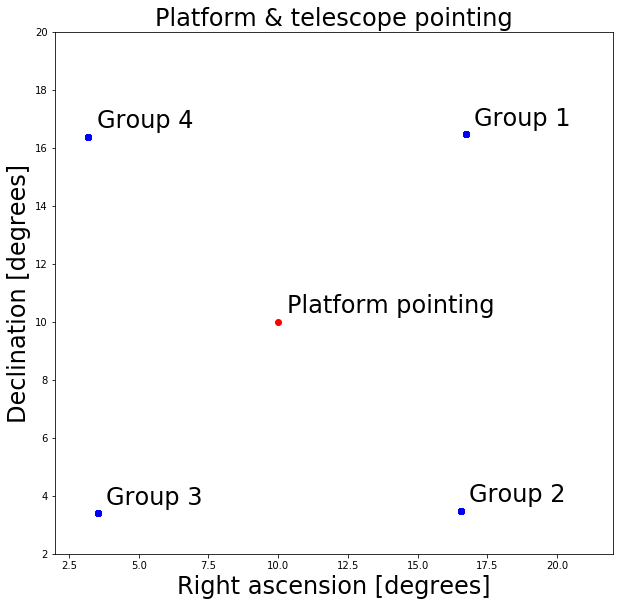

In [10]:
# Layout

fig = plt.figure(figsize = (10,10))
ax = fig.add_subplot(111)
fig.subplots_adjust(top=0.85)
ax.set_title('Platform & telescope pointing', fontsize = 24)
ax.set_xlabel('Right ascension [degrees]', fontsize = 24)
ax.set_ylabel('Declination [degrees]', fontsize = 24)
#ax.axis([150, 250, -80, -55])

#ax.annotate('Towards the south celestial pole', xy = (180, -75), xytext=(180, -73), arrowprops=dict(facecolor='black', shrink=0.05), fontsize = 20)

offsetX = 0.3
offsetY = 0.3

# Platform pointing

ax.plot([raPlatform], [decPlatform], "ro")
ax.text(raPlatform + offsetX, decPlatform + offsetY, r'Platform pointing', fontsize=24)

# Telescope pointing

ax.plot(raTelescopePointings, decTelescopePointings, "bo")

for index in range(numTelescopeGroups):
   ax.text(raTelescopePointings[index * numTelescopesPerGroup] + offsetX, decTelescopePointings[index * numTelescopesPerGroup] + offsetY, "Group " + str(index + 1), fontsize = 24)

plt.xlim([2, 22])
plt.ylim([2, 20])

### Which CCD was Selected by which Telescope (Group)?

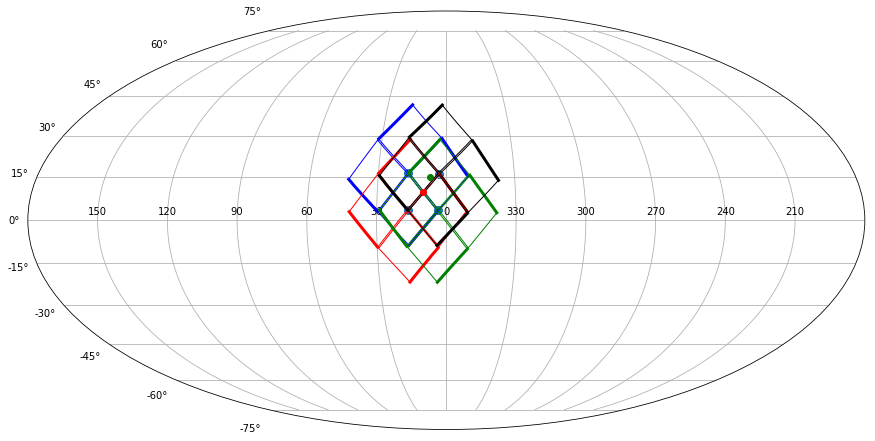

In [11]:
fig = plt.figure(figsize = (15, 15))
axes = fig.add_subplot(111, projection="mollweide")
axes.grid(True)

sim = Simulation("dummy", inputFile)
azimuthAngles = sim["CameraGroups/AzimuthAngle"]
tiltAngles = sim["CameraGroups/TiltAngle"]

for group in range(0,4):
    
    ccdCodes = ['1', '2', '3', '4']


    # Set up the colors to be used to draw each CCD. 
    # Different CCDs have different colors.

    #color = {'A': 'b', 'AF': 'b', 'B': 'r', 'BF': 'r', 'C': 'g', 'CF': 'g', 'D': 'k', 'DF': 'k'}
    color = ['b', 'r', 'g', 'k']
    
    # Plot each of the 4 CCDs

    for ccdCode in ccdCodes:

        # Get the focal plane FP' coordinates of the CCD corners  [mm]

        cornersXmm, cornersYmm = rf.computeCCDcornersInFocalPlane(ccdCode, pixelSize)

        # Compute the equatorial sky coordinates [rad] from the the focal plane FP' coordinates [mm] of the corners

        ra, dec = rf.focalPlaneToSkyCoordinates(cornersXmm, cornersYmm, math.radians(raPlatform), math.radians(decPlatform), solarPanelOrientation, math.radians(tiltAngles[group]), math.radians(azimuthAngles[group]), math.radians(focalPlaneAngle), focalLength)
                
        # Repeat the coordinates of the 1st corner, to plot a nice closed loop

        ra  = np.append(ra, ra[0])
        dec = np.append(dec, dec[0])

        # The sky projection assumes a longitude in [-pi, +pi] rather than [0, 2* pi]
        # And the longitude should be reversed so that East is to the left
        
        ra[ra>np.pi] -= 2*np.pi
        ra = -ra
 
        # Plot the CCD
    
        axes.plot(ra, dec, c=color[group], linewidth=1)

        # Overplot the row closest to the readout register with a thicker line

        axes.plot([ra[0], ra[1]], [dec[0], dec[1]], c=color[group], linewidth=3)
        

# Adapt the tick labels on the x-axis to take into account the origin shift
    
tickLabels = np.array([150, 120, 90, 60, 30, 0, 330, 300, 270, 240, 210])
tickLabels = np.remainder(tickLabels+360, 360)
axes.set_xticklabels(tickLabels)      

# Overplot the telescope pointing and the platform pointing

plt.scatter(np.deg2rad(-raTelescopePointings), np.deg2rad(decTelescopePointings), s=50)
plt.plot(np.deg2rad([-raPlatform]), np.deg2rad([decPlatform]), "ro")
plt.plot(np.deg2rad([-raCenter]), np.deg2rad([decCenter]), "go")

#### Telescope group 1: CCD 1 selected

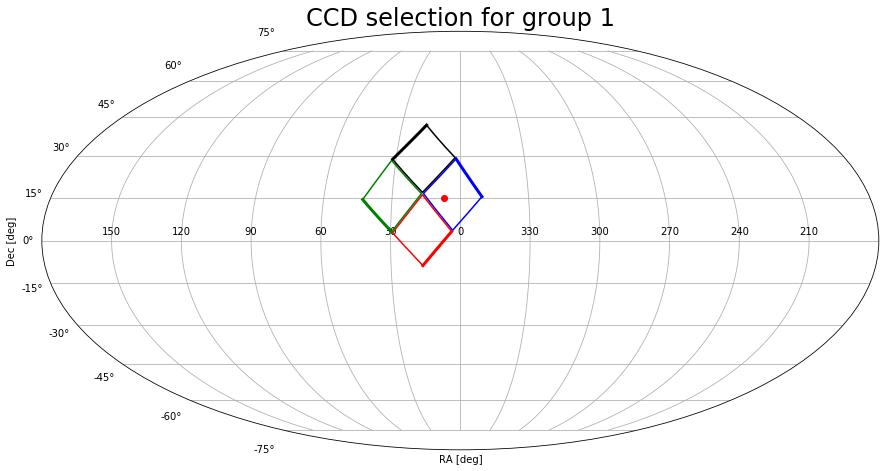

In [12]:
fig = plt.figure(figsize = (15, 15))
axes = drawCCDsInSkyMollweide(fig, math.radians(raPlatform), math.radians(decPlatform), solarPanelOrientation, math.radians(tiltAngles[0]), math.radians(azimuthAngles[0]), math.radians(focalPlaneAngle), focalLength, pixelSize, normal=True)

plt.title('CCD selection for group 1', fontsize = 24)
axes.plot(np.deg2rad([-raCenter]), np.deg2rad([decCenter]), "ro")

#### Telescope group 2: CCD 1 selected

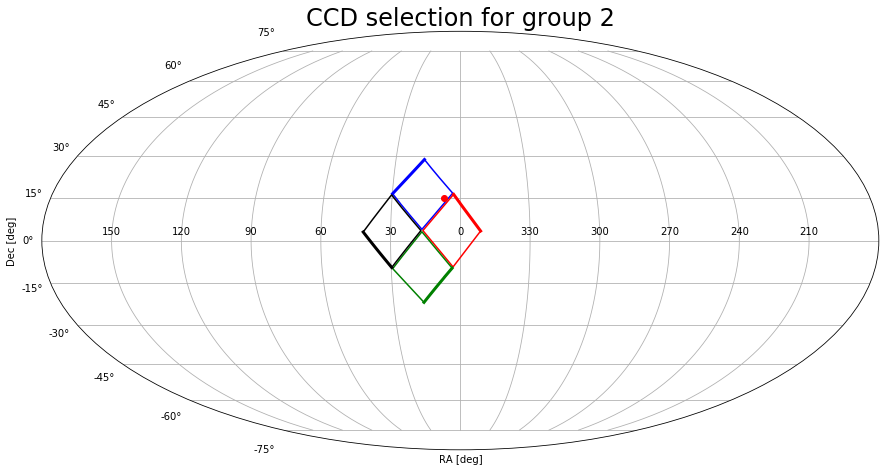

In [13]:
fig = plt.figure(figsize = (15, 15))
axes = drawCCDsInSkyMollweide(fig, math.radians(raPlatform), math.radians(decPlatform), solarPanelOrientation, math.radians(tiltAngles[1]), math.radians(azimuthAngles[1]), math.radians(focalPlaneAngle), focalLength, pixelSize, normal=True)

plt.title('CCD selection for group 2', fontsize = 24)
axes.plot(np.deg2rad([-raCenter]), np.deg2rad([decCenter]), "ro")

## Telescope group 3: CCD 4 selected

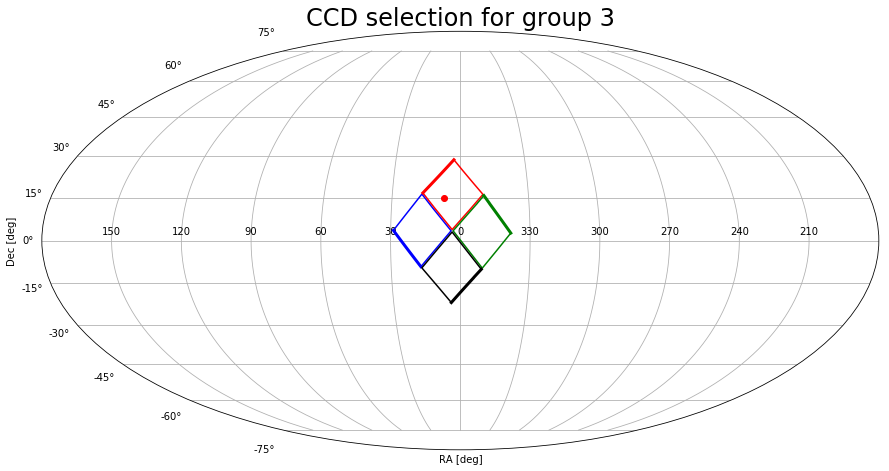

In [14]:
fig = plt.figure(figsize = (15, 15))
axes = drawCCDsInSkyMollweide(fig, math.radians(raPlatform), math.radians(decPlatform), solarPanelOrientation, math.radians(tiltAngles[2]), math.radians(azimuthAngles[2]), math.radians(focalPlaneAngle), focalLength, pixelSize, normal=True)

plt.title('CCD selection for group 3', fontsize = 24)
axes.plot(np.deg2rad([-raCenter]), np.deg2rad([decCenter]), "ro")

## Telescope group 4: CCD 2 selected

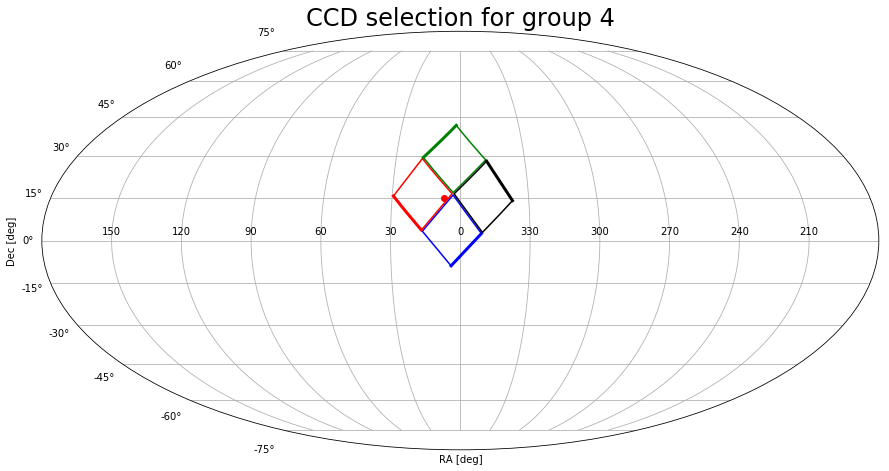

In [15]:
fig = plt.figure(figsize = (15, 15))
axes = drawCCDsInSkyMollweide(fig, math.radians(raPlatform), math.radians(decPlatform), solarPanelOrientation, math.radians(tiltAngles[3]), math.radians(azimuthAngles[3]), math.radians(focalPlaneAngle), focalLength, pixelSize, normal=True)

plt.title('CCD selection for group 4', fontsize = 24)
axes.plot(np.deg2rad([-raCenter]), np.deg2rad([decCenter]), "ro")